# Pharmacy Desert Risk Prediction Using Machine Learnin


Week 3 – Temporal Modeling – XGBoost, LSTM

## Loading Data

Importing the merged dataset

In [6]:
import pandas as pd
import numpy as np

# Data Importation
# Getting cleaned and merged per state data
df = pd.read_csv("df_final_pharmacy_cleaned.csv")
# Getting Overview
df.head()


,State_y,County,county_fips,year,pharmacies_per_county_year,tot_claims,tot_30day_fills,tot_drug_cost,tot_days_supply,tot_beneficiaries,avg_bene_age,Health_Outcome_Rank,Health_Factor_Rank,labor_force,employed,unemployed,unemployment_rate
0,AK,Aleutians East,2013,2014,0,1543,2515.200000,101236.20,69125,252,72.206522,16.0,16.0,2219,2121,98,4.4
1,AK,Aleutians East,2013,2015,1,1265,2095.733333,87137.34,58674,211,70.535299,16.0,16.0,2472,2395,77,3.1
2,AK,Aleutians East,2013,2016,2,1977,3104.066667,144648.87,84565,250,66.715694,16.0,16.0,2589,2523,66,2.5
3,AK,Aleutians East,2013,2018,2,1451,2550.366667,112767.33,67572,435,69.874315,16.0,16.0,2316,2250,66,2.8
4,AK,Aleutians East,2013,2019,1,92,136.433333,11567.95,2963,42,70.142857,16.0,16.0,2544,2483,61,2.4


# Feature Engineering for Target: Temporal Deseart Formation

**Pharmacy Accessibility Pressure (PAP) Index** - measures the beneficiary load per pharmacy by dividing the total number of beneficiaries (tot_beneficiaries) by the total number of pharmacies in the given county. Given as bene_per_pharmacy_PAP

**Temporal Desert Formation (TDF) Feature** - Tracks the percentage change in the **Pharmacy Accessibility Pressure (PAP) Index** across years for each of the counties. Given as access_pressure_change_TDF and such that:

- Negative values = accessibility improved

- Near zero = stable accessibility

- Positive values = worsening accessibility

- Large positive values = rapid deterioration (potential desert formation)


**Desert_Formation_Risk** - Binary feature for a county as either at high risk or low risk of pharmacy desert formation based on the percentage change in the Pharmacy Accessibility Pressure (PAP) Index (≥25% change = High Risk, otherwise Low Risk).



In [7]:
# Creating the Pharmacy Accessibility Pressure Index (PAP)
df["bene_per_pharmacy_PAP"] = (
    df["tot_beneficiaries"] /
    df["pharmacies_per_county_year"]
)

# Creating a lag for Accessibility Pressure Index
df["bene_per_pharmacy_PAP_lag"] = (
    df.groupby("county_fips")["bene_per_pharmacy_PAP"]
      .shift(1)
)


# Creating Temporal Desert Formation Feature
df["access_pressure_change_TDF"] = (
    (df["bene_per_pharmacy_PAP"] - df["bene_per_pharmacy_PAP_lag"])/df["bene_per_pharmacy_PAP_lag"]
)


In [8]:
# Pharmacy Desert Formation Risk Feature

df["Desert_Formation_Risk"] = np.where(
    df["access_pressure_change_TDF"] >= 0.25,
    "High Risk",
    "Low Risk"
)


In [9]:
# Replace inf and -inf with NaN
df = df.replace([np.inf, -np.inf], np.nan)

# Temporal Modeling

Data Preprocessing for Temporal Modelling

## Target and Features

In [10]:
df.columns

Index(['State_y', 'County', 'county_fips', 'year',
       'pharmacies_per_county_year', 'tot_claims', 'tot_30day_fills',
       'tot_drug_cost', 'tot_days_supply', 'tot_beneficiaries', 'avg_bene_age',
       'Health_Outcome_Rank', 'Health_Factor_Rank', 'labor_force', 'employed',
       'unemployed', 'unemployment_rate', 'bene_per_pharmacy_PAP',
       'bene_per_pharmacy_PAP_lag', 'access_pressure_change_TDF',
       'Desert_Formation_Risk'],
      dtype='object')

In [11]:
# Features' Columns
features = [
    'tot_claims', 'tot_30day_fills','tot_drug_cost', 'tot_days_supply',
    #'tot_beneficiaries', # Used to compute target
    'avg_bene_age','Health_Outcome_Rank',
    #'Health_Factor_Rank', # Removed in model improvement
    'unemployment_rate'
]

# Target Variable
target = 'Desert_Formation_Risk'

In [12]:
# Removing NAs due to lag creation
df_model = df.dropna().copy()

# Data Partitions
train_df = df_model[df_model["year"] <= 2020]
test_df = df_model[df_model["year"] > 2020]

# Training Features and Targets
X_train = train_df[features]
y_train = train_df[target]

# Testing Features and Targets
X_test = test_df[features]
y_test = test_df[target]

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Fit on training labels
y_train = le.fit_transform(y_train)

# Transform test labels using the same mapping
y_test = le.transform(y_test)


In [13]:
# Sizes
train_size = len(train_df)
test_size = len(test_df)
total_size = len(df_model)

# Proportions
print(f"Train size: {train_size} ({train_size/total_size:.2%})")
print(f"Test size:  {test_size} ({test_size/total_size:.2%})")
print(f"Total size: {total_size}")

Train size: 13812 (83.67%)
Test size:  2695 (16.33%)
Total size: 16507


## XGBoost Model

In [14]:
from sklearn.decomposition import PCA
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler

# Model Initialization
model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss'
)

# Fitting Model
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [15]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Predictions
y_pred = model.predict(X_test)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Value": [accuracy, precision, recall, f1]
})

print(results)

# Detailed report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

      Metric     Value
0   Accuracy  0.821521
1  Precision  0.748812
2     Recall  0.821521
3   F1-Score  0.766883

Classification Report:
              precision    recall  f1-score   support

           0       0.30      0.06      0.09       448
           1       0.84      0.97      0.90      2247

    accuracy                           0.82      2695
   macro avg       0.57      0.51      0.50      2695
weighted avg       0.75      0.82      0.77      2695


Confusion Matrix:
[[  25  423]
 [  58 2189]]


<Figure size 1400x600 with 0 Axes>

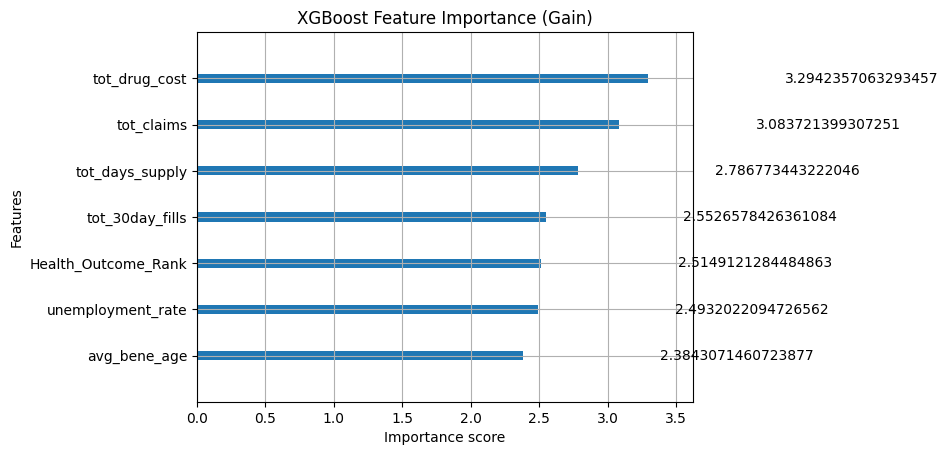

In [16]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plot_importance(
    model,
    importance_type='gain',  # gain, weight, cover
    max_num_features=20
)

plt.title("XGBoost Feature Importance (Gain)")
plt.show()

## LSTM Model

In [17]:
import random
import torch
def set_seed(seed=1):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(1)

In [18]:
# Scaling Data
# Scalers
scaler_X = StandardScaler()
scaler_y = StandardScaler()

# Scaling Training Set
train_df[features] = scaler_X.fit_transform(train_df[features])

# Scaling Testing Set
test_df[features] = scaler_X.transform(test_df[features])

# Encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

train_df[target] = le.fit_transform(train_df[target])
test_df[target] = le.transform(test_df[target])

/tmp/ipykernel_4746/3802844264.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df[features] = scaler_X.fit_transform(train_df[features])
/tmp/ipykernel_4746/3802844264.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df[features] = scaler_X.transform(test_df[features])
/tmp/ipykernel_4746/3802844264.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation

In [19]:
# Train Sequence

# Sequence Length
SEQ_LEN = 2

# Sequences
X_train_seq, y_train_seq = [], []

for county in train_df["County"].unique():
    county_df = train_df[train_df["County"] == county]

    X = county_df[features].values
    y = county_df[target].values

    for i in range(len(county_df) - SEQ_LEN):
        X_train_seq.append(X[i:i+SEQ_LEN])
        y_train_seq.append(y[i+SEQ_LEN])

In [20]:
# Test Sequence

# Sequences
X_test_seq, y_test_seq = [], []

for county in test_df["County"].unique():
    county_df = test_df[test_df["County"] == county]

    X = county_df[features].values
    y = county_df[target].values

    for i in range(len(county_df) - SEQ_LEN):
        X_test_seq.append(X[i:i+SEQ_LEN])
        y_test_seq.append(y[i+SEQ_LEN])

In [21]:
# Model Function
import torch
import torch.nn as nn

class LSTMModel(nn.Module):
    def __init__(
        self,
        input_size,
        hidden_size=64,
        num_layers=2,
        num_classes=1
    ):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out, _ = self.lstm(x)

        # last timestep
        out = out[:, -1, :]

        # logits
        out = self.fc(out)

        return out.squeeze(1)

In [22]:
import torch
import torch.nn as nn
import torch.optim as optim


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Creating Tensors
X_train = torch.tensor(np.array(X_train_seq), dtype=torch.float32).to(device)
y_train = torch.tensor(np.array(y_train_seq), dtype=torch.float32).to(device)

X_test = torch.tensor(np.array(X_test_seq), dtype=torch.float32).to(device)
y_test = torch.tensor(np.array(y_test_seq), dtype=torch.float32).to(device)

# Model
model = LSTMModel(
    input_size=X_train.shape[2],
    hidden_size=64,
    num_layers=2,
    num_classes=1
).to(device)

In [23]:
# Training Setup
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

optimizer.zero_grad()

outputs = model(X_train).squeeze()

loss = criterion(outputs, y_train)

loss.backward()
optimizer.step()

In [24]:
# Training Loop
train_losses = []

num_epochs = 100

for epoch in range(num_epochs):

    model.train()

    optimizer.zero_grad()

    outputs = model(X_train)

    loss = criterion(outputs, y_train)

    loss.backward()

    optimizer.step()

    # Store loss
    train_losses.append(loss.item())

    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch [{epoch+1}/{num_epochs}], "
            f"Loss: {loss.item():.4f}"
        )

Epoch [10/100], Loss: 0.6685
Epoch [20/100], Loss: 0.6199
Epoch [30/100], Loss: 0.5488
Epoch [40/100], Loss: 0.4944
Epoch [50/100], Loss: 0.4942
Epoch [60/100], Loss: 0.4859
Epoch [70/100], Loss: 0.4844
Epoch [80/100], Loss: 0.4818
Epoch [90/100], Loss: 0.4799
Epoch [100/100], Loss: 0.4776


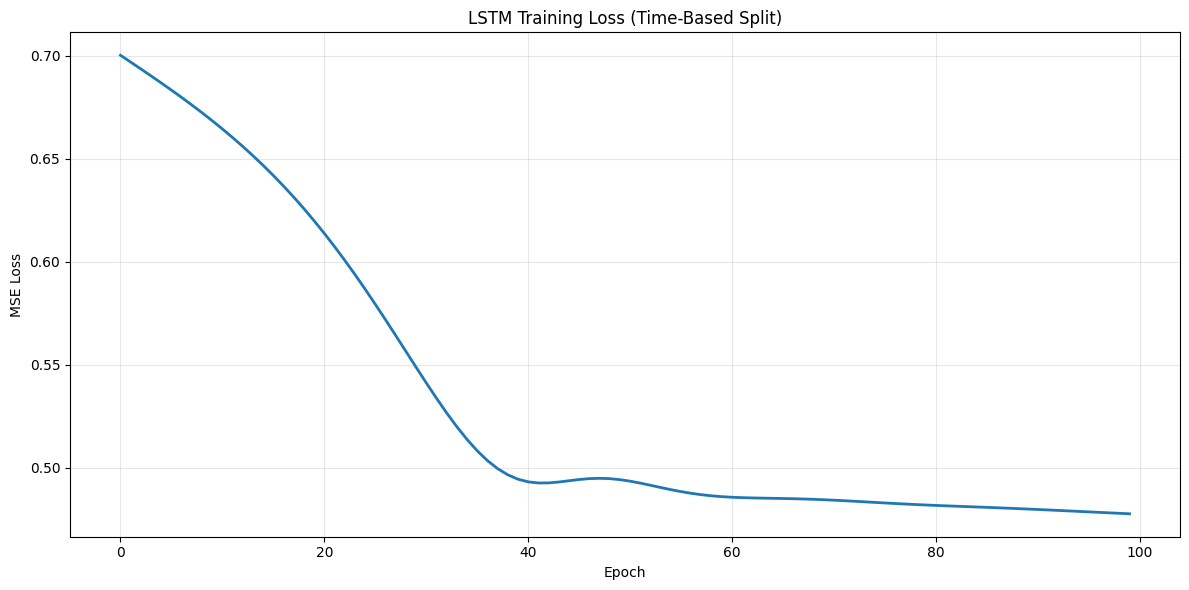

In [25]:
# Loss Curve
plt.figure(figsize=(12, 6))
plt.plot(train_losses, linewidth=2)

plt.title("LSTM Training Loss (Time-Based Split)")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [26]:
# Predictions
import numpy as np
import torch

model.eval()

preds = []

with torch.no_grad():
    for i in range(len(X_test)):

        xb = X_test[i].unsqueeze(0).to(device)

        logits = model(xb).squeeze()

        prob = torch.sigmoid(logits)   # converting logit to probability

        pred_class = (prob >= 0.5).int().cpu().item()

        preds.append(pred_class)

preds = np.array(preds)

In [27]:
# True Labels
y_true = y_test.cpu().numpy()

In [28]:
# Performance Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

accuracy = accuracy_score(y_true, preds)
precision = precision_score(y_true, preds, average='weighted')
recall = recall_score(y_true, preds, average='weighted')
f1 = f1_score(y_true, preds, average='weighted')

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_true, preds))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_true, preds))

Accuracy:  0.8253
Precision: 0.6944
Recall:    0.8253
F1-score:  0.7542

Classification Report:

              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00       114
         1.0       0.83      0.99      0.90       573

    accuracy                           0.83       687
   macro avg       0.42      0.49      0.45       687
weighted avg       0.69      0.83      0.75       687


Confusion Matrix:

[[  0 114]
 [  6 567]]


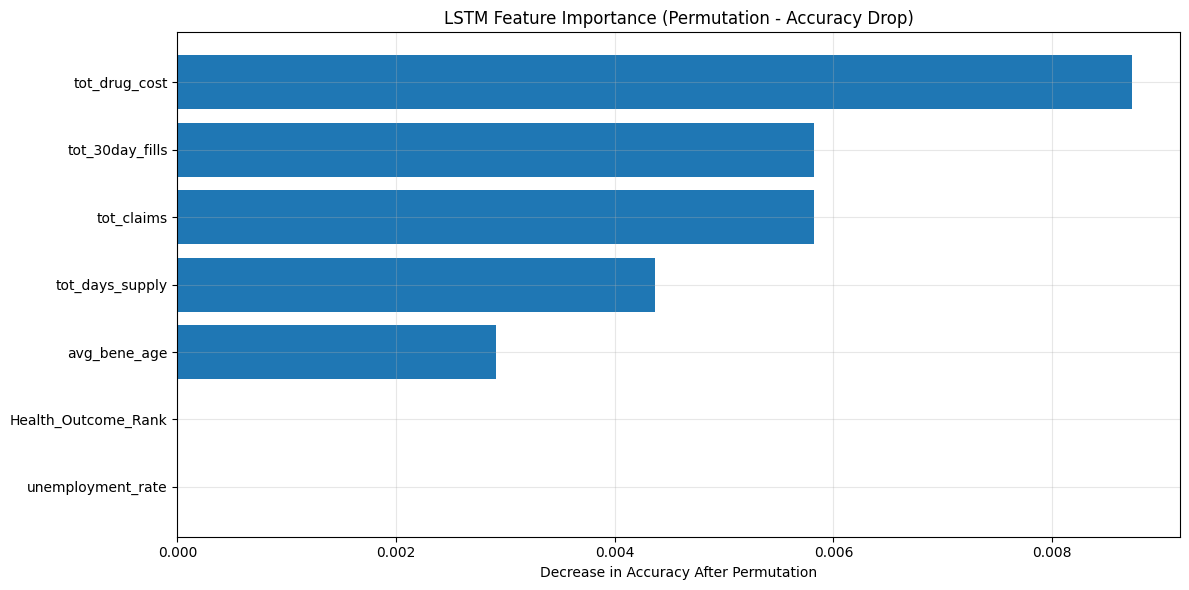

In [29]:
import numpy as np
import torch
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt


def permutation_importance_lstm(model, X_test, y_test, feature_names, device):

    model.eval()

    # Baseline Predictions
    baseline_preds = []

    with torch.no_grad():
        for i in range(len(X_test)):
            xb = X_test[i].unsqueeze(0).to(device)

            logits = model(xb).squeeze()

            prob = torch.sigmoid(logits)

            pred = (prob >= 0.5).int().cpu().item()

            baseline_preds.append(pred)

    baseline_preds = np.array(baseline_preds)
    baseline_acc = accuracy_score(y_test, baseline_preds)

    importances = []

    # Permutation Loop
    for i, feature in enumerate(feature_names):

        X_perm = X_test.clone()

        # shuffle feature across samples
        idx = torch.randperm(X_perm.size(0))
        X_perm[:, :, i] = X_perm[idx, :, i]

        preds = []

        with torch.no_grad():
            for j in range(len(X_perm)):

                xb = X_perm[j].unsqueeze(0).to(device)

                logits = model(xb).squeeze()

                prob = torch.sigmoid(logits)

                pred = (prob >= 0.5).int().cpu().item()

                preds.append(pred)

        preds = np.array(preds)
        acc = accuracy_score(y_test, preds)

        # importance = drop in performance
        importances.append(abs(baseline_acc - acc))

    return importances

feature_names = features

importances = permutation_importance_lstm(
    model,
    X_test,
    y_test.cpu().numpy(),
    feature_names,
    device
)

plt.figure(figsize=(12, 6))

idx = np.argsort(importances)

plt.barh(
    range(len(feature_names)),
    np.array(importances)[idx]
)

plt.yticks(
    range(len(feature_names)),
    np.array(feature_names)[idx]
)

plt.title("LSTM Feature Importance (Permutation - Accuracy Drop)")
plt.xlabel("Decrease in Accuracy After Permutation")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Temporal Modeling Summary

This notebook trained and evaluated temporal models for pharmacy desert risk prediction.

Completed steps:
• Created PAP and TDF features.
• Created the Desert Formation Risk target label.
• Split the dataset using a time-based train-test split.
• Trained an XGBoost classifier as the structured tabular baseline model.
• Trained an LSTM model using 2-year county sequences.
• Evaluated models using accuracy, precision, recall, F1-score, classification report, and confusion matrix.
• Compared XGBoost and LSTM performance for Low-Risk and High-Risk classification.

Key finding:
XGBoost gave the best practical baseline performance because it worked well with structured county-year data and provided interpretable feature importance. LSTM learned temporal patterns, but it struggled to detect High-Risk cases due to class imbalance.

Next step:
The next notebook will extend modeling using spatial-temporal and higher-order network models such as ST-GNN, HGNN, and Tensor Train.